In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

read in the final features data

In [2]:
company_data = pd.read_csv('./selected_features_data/company_data_ff.csv')
company_data

,entity_urn,ownership_status,United States Sales,United States Engineering,country_multiplier,sales_ratio,adj_hc_ratio,investor_1,investor_2,Prior VC Backed Founder_count,...,employee_highlight_YC Backed Founder,employee_highlight_Prior VC Backed Executive,employee_highlight_Founder Turned Operator,employee_highlight_Current Student,employee_highlight_HBCU Alum,employee_highlight_Jack of All Trades,employee_highlight_money_club_count,employee_highlight_seasoned_count,employee_highlight_top_institution_experience_count,num_unique_vc_backers
0,urn:harmonic:company:3676293,PRIVATE,0,0,1.0,0.062500,1.000000,1,0,1,...,2,1,0,0,0,0,0,2,11,4
1,urn:harmonic:company:3823516,PRIVATE,0,1,1.0,0.000000,0.990000,2,0,3,...,3,3,0,3,0,0,0,3,12,7
2,urn:harmonic:company:12475768,PRIVATE,2,2,1.0,0.100000,1.000000,1,0,1,...,3,2,0,0,0,0,1,1,10,2
3,urn:harmonic:company:49899178,PRIVATE,0,0,1.0,0.090090,0.850000,1,0,2,...,3,3,0,0,0,0,0,6,5,12
4,urn:harmonic:company:11125538,PRIVATE,0,1,1.0,0.074074,0.964286,3,1,3,...,3,3,0,0,0,0,2,8,21,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14830,urn:harmonic:company:4418743,PRIVATE,0,0,1.0,0.000000,1.000000,0,0,0,...,0,0,0,0,0,0,0,13,2,0
14831,urn:harmonic:company:4501758,ACQUIRED_OR_MERGED,0,0,1.0,0.090090,0.850000,0,0,0,...,0,0,0,0,0,0,0,0,0,2
14832,urn:harmonic:company:651225,PRIVATE,0,0,1.0,0.090090,0.850000,0,0,0,...,0,2,0,0,0,0,0,6,13,0
14833,urn:harmonic:company:52637542,PRIVATE,0,1,1.0,0.090090,0.850000,1,0,2,...,0,7,0,0,0,0,0,16,10,5


In [3]:
target_company_data = pd.read_csv('./selected_features_data/target_company_data_ff.csv')
target_company_data

,entity_urn,ownership_status,United States Sales,United States Engineering,country_multiplier,sales_ratio,adj_hc_ratio,investor_1,investor_2,Prior VC Backed Founder_count,...,employee_highlight_YC Backed Founder,employee_highlight_Prior VC Backed Executive,employee_highlight_Founder Turned Operator,employee_highlight_Current Student,employee_highlight_HBCU Alum,employee_highlight_Jack of All Trades,employee_highlight_money_club_count,employee_highlight_seasoned_count,employee_highlight_top_institution_experience_count,num_unique_vc_backers
0,urn:harmonic:company:1443095,PRIVATE,4,23,1.0,0.163399,0.987097,3,0,7,...,2,3,2,0,0,0,3,10,62,18
1,urn:harmonic:company:1990249,PRIVATE,1,1,1.0,0.090090,0.850000,1,0,0,...,0,8,0,1,0,0,0,20,34,10
2,urn:harmonic:company:3075425,PRIVATE,0,1,1.0,0.000000,0.848148,1,0,1,...,1,9,0,0,0,0,1,26,24,18
3,urn:harmonic:company:10819970,PRIVATE,1,3,1.0,0.090090,0.850000,3,0,1,...,0,12,0,0,0,0,1,34,43,22
4,urn:harmonic:company:3928206,PRIVATE,1,1,1.0,0.090090,0.850000,3,0,2,...,0,14,0,0,1,0,2,34,19,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,urn:harmonic:company:1842794,PRIVATE,5,2,1.0,0.000000,1.000000,3,0,1,...,0,15,0,0,0,0,0,30,28,10
57,urn:harmonic:company:48201423,PRIVATE,0,1,1.0,0.090090,0.850000,1,0,2,...,1,5,0,0,0,0,0,7,13,14
58,urn:harmonic:company:773593,PRIVATE,2,0,1.0,0.211268,0.946667,4,0,1,...,1,5,0,0,0,0,1,10,8,8
59,urn:harmonic:company:1869576,PRIVATE,2,4,1.0,0.000000,0.929412,8,0,2,...,3,1,0,0,0,0,0,5,16,19


## Handle missing values
- analyze missing value stats between company data and target company data

Because there is a huge imbalance between the target (positive) group compared to the rest of the data, we have to keep in mind that the missing% is not equivalent between the target group and the rest of the data. However the difference in their missing% can tell us if a feature could be an indicator of a target company. We do have to keep in mind not to blindly use a feature just because its present in the target companies but not in the rest of the data because that can cause overfitting.

In [4]:
unique_dtypes = company_data.dtypes.unique()
unique_dtypes

array([dtype('O'), dtype('int64'), dtype('float64')], dtype=object)

In [5]:
def clean_missing_data(df):
    # print(df.select_dtypes(include=['string']).columns)
    # print(df.select_dtypes(include=['object']).columns)

    for col in df.select_dtypes(include=['O']).columns:
        # replace empty strings with NaN
        df.loc[:, col] = df[col].str.strip()
        df.loc[:, col] = df[col].replace('', np.nan)

    return df

In [6]:
company_data = clean_missing_data(company_data)
target_company_data = clean_missing_data(target_company_data)

In [7]:
# calculate missing % for each group
missing_target = target_company_data.isna().mean() * 100
missing_non_target = company_data.isna().mean() * 100

# combine into one table for comparison
missing_comparison = pd.DataFrame({
    'missing_pct_target': missing_target,
    'missing_pct_non_target': missing_non_target,
    'missing_pct_diff': (missing_target - missing_non_target).abs()
}).sort_values(by='missing_pct_diff', ascending=False)

missing_comparison

,missing_pct_target,missing_pct_non_target,missing_pct_diff
adj_emp_delta_12m,27.868852,0.000000,27.868852
headcount_growth_12m,27.868852,0.000000,27.868852
linkedin_follower_trend,31.147541,4.435457,26.712084
linkedin_follower_growth_12m,31.147541,5.513987,25.633554
followers_per_linkedin_employee,37.704918,13.764746,23.940172
...,...,...,...
num_valid_months,0.000000,0.000000,0.000000
headcount_volatility_score,0.000000,0.000000,0.000000
current_max_ratio,0.000000,0.000000,0.000000
linkedin_employees,0.000000,0.000000,0.000000


## Impute missing values

In [8]:
for col in missing_comparison[missing_comparison['missing_pct_diff'] != 0].index:
    if 'peak_month' in col:
        target_company_data[col] = target_company_data[col].fillna(-1)
        company_data[col] = company_data[col].fillna(-1)
    elif 'funding_stage' in col or 'last_funding_type' in col:
        target_company_data[col] = target_company_data[col].fillna('UNKNOWN')
        company_data[col] = company_data[col].fillna('UNKNOWN')
    else:
        target_company_data[col] = target_company_data[col].fillna(-1)
        company_data[col] = company_data[col].fillna(-1)

In [9]:
# Check if all missing values were imputed
print(target_company_data.isnull().sum().sort_values(ascending=False))
print(company_data.isnull().sum().sort_values(ascending=False))

entity_urn                    0
emps/funds_m                  0
funding_stage                 0
last_funding_total            0
last_funding_type             0
                             ..
trailing_growth_avg           0
headcount_volatility_score    0
num_valid_months              0
earliest_valid_month          0
num_unique_vc_backers         0
Length: 77, dtype: int64
entity_urn                    0
emps/funds_m                  0
funding_stage                 0
last_funding_total            0
last_funding_type             0
                             ..
trailing_growth_avg           0
headcount_volatility_score    0
num_valid_months              0
earliest_valid_month          0
num_unique_vc_backers         0
Length: 77, dtype: int64


## Compare feature distributions between the two groups:
- p-value ≈ probability that the two groups are NOT different by chance.

- Small p-value (e.g., < 0.02) 
    - → Unlikely that the difference between the two groups happened randomly →
    - → The feature behaves differently between target and non-target →
    - → Useful for the model to tell them apart!

In [10]:
from scipy.stats import mannwhitneyu, chi2_contingency

def statistical_feature_test(df_target, df_rest, feature, threshold=0.02):
    try:
        # Numerical feature
        target_values = df_target[feature].dropna()
        rest_values = df_rest[feature].dropna()

        if np.issubdtype(target_values.dtype, np.number):
            stat, p_value = mannwhitneyu(target_values, rest_values, alternative='two-sided')
        else:
            # Categorical feature
            contingency_table = pd.crosstab(df_target[feature], df_rest[feature])
            stat, p_value, _, _ = chi2_contingency(contingency_table)
        
        return p_value < threshold
    except Exception as e:
        print(f"Skipping {feature} due to error: {e}")
        return False

In [11]:
good_features = [f for f in company_data.columns if f != 'entity_urn' and statistical_feature_test(
    target_company_data.loc[:, target_company_data.columns != 'entity_urn'],
    company_data.loc[:, company_data.columns != 'entity_urn'],
    f)]
len(good_features)

48

In [12]:
bad_features = [f for f in company_data.columns if f not in good_features]
bad_features

['entity_urn',
 'ownership_status',
 'sales_ratio',
 'adj_hc_ratio',
 'investor_2',
 'company_region',
 'headcount_growth_12m',
 'max_headcount',
 'linkedin_follower_growth_12m',
 'linkedin_follower_peak_month',
 'linkedin_current_peak_count_ratio',
 'linkedin_follower_trend',
 'followers_per_linkedin_employee',
 'twitter_follower_peak_month',
 'twitter_follower_trend',
 'emps/year',
 'emps/funds_m',
 'adj_emp_delta_12m',
 'funding_total',
 'last_funding_type',
 'last_funding_total',
 'funding_stage',
 'adj_hc_ratio.1',
 'dominant_function',
 'dominant_emp_role',
 'top_region',
 'employee_highlight_Founder Turned Operator',
 'employee_highlight_HBCU Alum',
 'employee_highlight_Jack of All Trades']

In [13]:
target_company_data['target'] = 1
company_data['target'] = 0

X_train = pd.concat([target_company_data, company_data])
X_train = X_train[good_features + ['target', 'entity_urn']]
y_train = X_train['target']

entity_urns = X_train['entity_urn'].copy()
X_train = X_train.drop(columns=['target', 'entity_urn'])

## Handle constant features

drop features that are mostly constant (>99% same value across rows)
- no variance → the model (or any analysis) can't learn anything from a feature that’s always the same.
- extra noise → keeping it would just add unnecessary complexity.

In [14]:
def find_constant_columns(df):
    mostly_constant_cols = []

    for col in df.columns:
        if df[col].nunique(dropna=False) <= 2:
            mostly_constant_cols.append(col)

    print(f"Mostly constant columns: {mostly_constant_cols}")

find_constant_columns(X_train)

Mostly constant columns: []


## Feature importance 

In [15]:
from sklearn.preprocessing import LabelEncoder

def label_encode_dataframe(X):
    X_encoded = X.copy()
    for col in X_encoded.columns:
        if X_encoded[col].dtype == 'object':
            le = LabelEncoder()
            X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    return X_encoded

In [16]:
# Before passing through the random forest for feature importance, we need to label encode the categorical features
X_train = label_encode_dataframe(X_train)

In [17]:
from sklearn.ensemble import RandomForestClassifier

# Use logistic regression vs random forest to select feature importance to look at gini importance
def feature_importance_selection(X_train, y_train, top_k=20):
    # Assume X_train is your feature matrix, y_train is your label
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    importances = rf.feature_importances_
    feature_names = X_train.columns 

    return importances, feature_names, rf

In [18]:
importances, feature_names, model = feature_importance_selection(X_train, y_train)

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

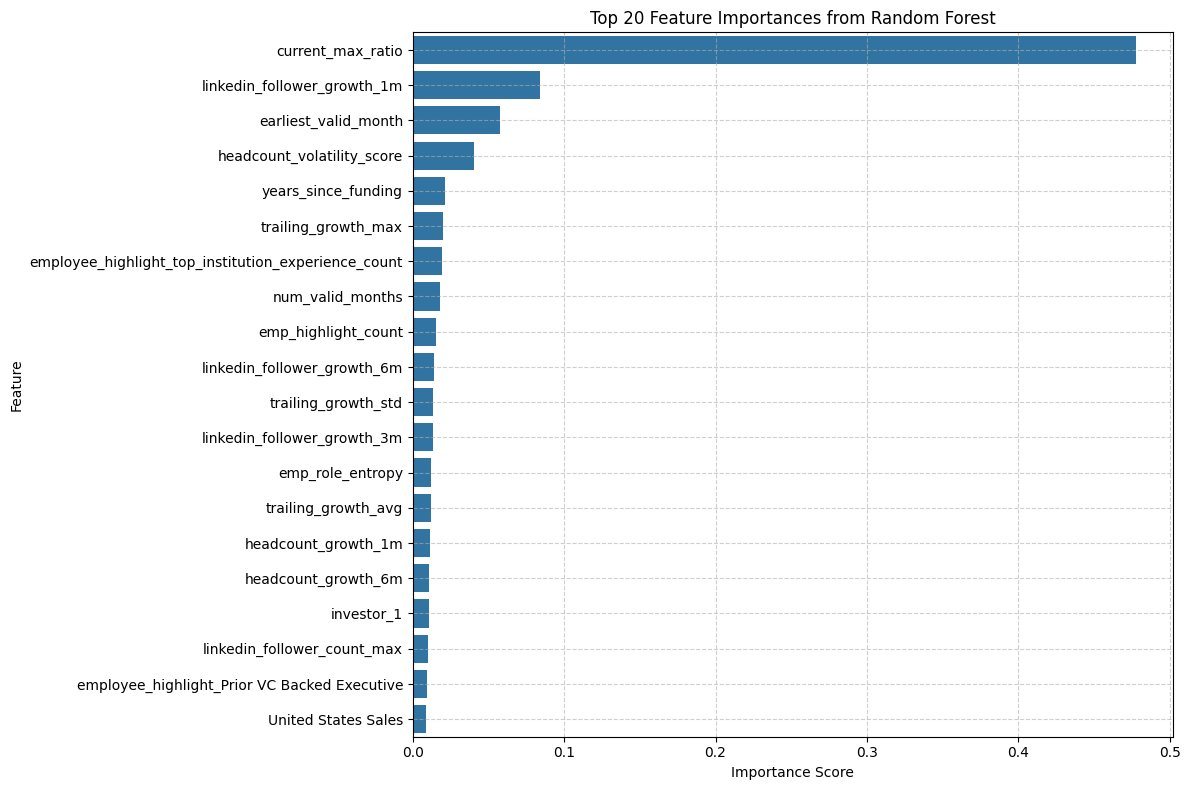

In [19]:
plt.figure(figsize=(12, 8))
sns.barplot(
    x='importance',
    y='feature',
    data=feature_importance_df.head(20),  # Top 20 features
    orient='h'
)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances from Random Forest')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


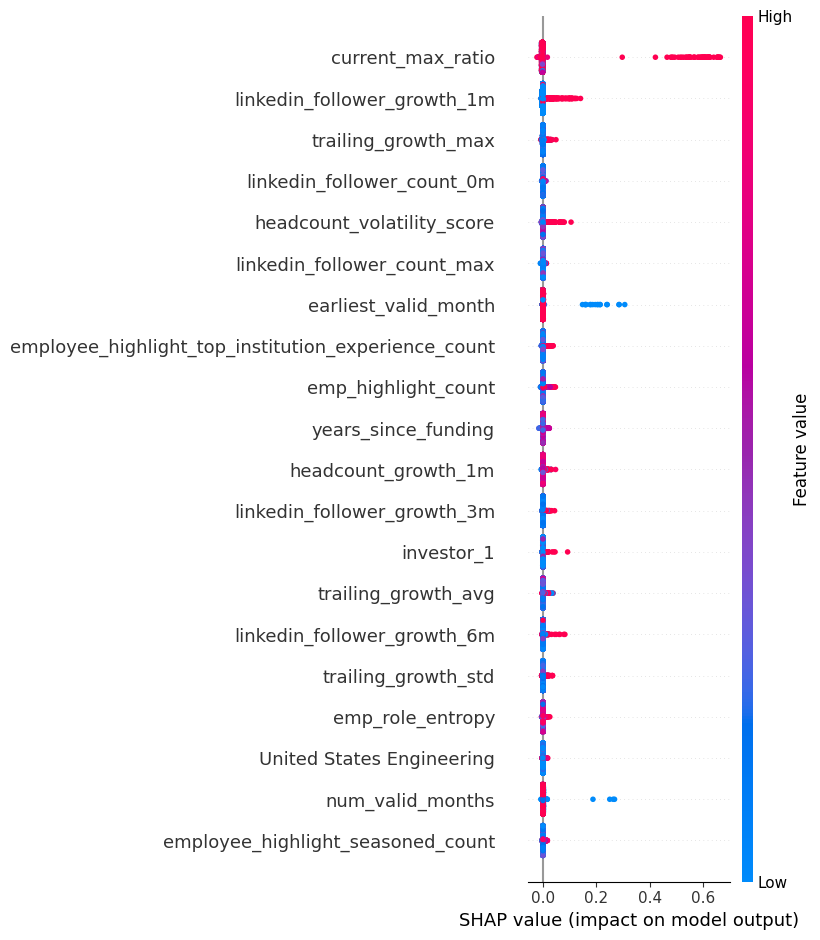

In [20]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)
shap.summary_plot(shap_values[1], X_train)

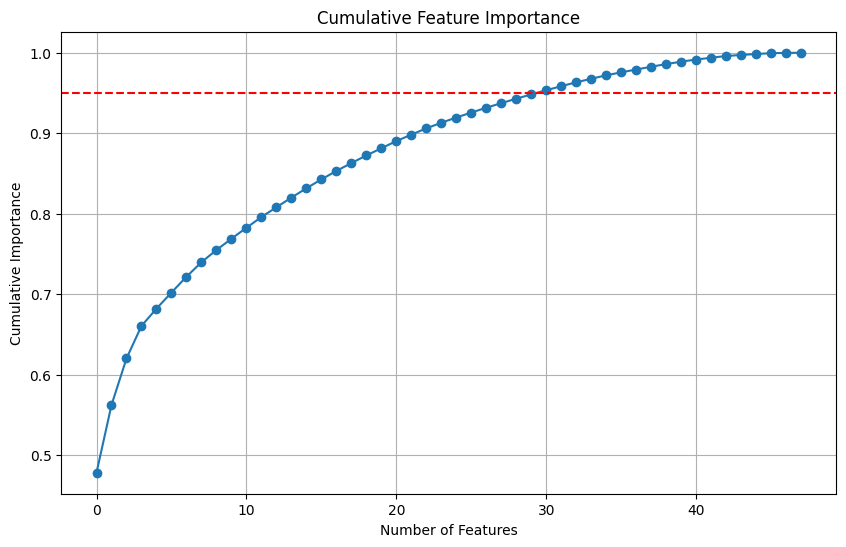

In [21]:
# Calculate cumulative importance
feature_importance_df['cumulative_importance'] = feature_importance_df['importance'].cumsum()

# Plot
plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(feature_importance_df)), feature_importance_df['cumulative_importance'], marker='o')
plt.xlabel('Number of Features')
plt.ylabel('Cumulative Importance')
plt.title('Cumulative Feature Importance')
plt.grid(True)
plt.axhline(y=0.95, color='red', linestyle='--')  # Optional: line at 95%
plt.show()

In [22]:
feature_importance_df.head(30)

,feature,importance,cumulative_importance
21,current_max_ratio,0.478005,0.478005
23,linkedin_follower_growth_1m,0.084126,0.562131
14,earliest_valid_month,0.057864,0.619994
16,headcount_volatility_score,0.040454,0.660448
35,years_since_funding,0.021510,0.681958
20,trailing_growth_max,0.020000,0.701957
46,employee_highlight_top_institution_experience_...,0.019613,0.721570
15,num_valid_months,0.018065,0.739635
34,emp_highlight_count,0.015183,0.754818
25,linkedin_follower_growth_6m,0.013971,0.768788


In [23]:
X_train = X_train[feature_importance_df.head(30)['feature']]

In [24]:
X_train = pd.concat([X_train, entity_urns], axis=1)

In [25]:
X_train.to_csv('./model_data/final_features.csv', index=False)
y_train.to_csv('./model_data/labels.csv', index=False)